# Preference Signal Detector — Layer 1
## Final Kaggle Notebook

Binary task:
- `0 = NO_PREFERENCE_SIGNAL`
- `1 = PREFERENCE_SIGNAL`

This layer only decides whether the user input contains at least one preference signal about **cost, power, performance, or reliability**.

Protocol: **TRAIN → VALIDATION → freeze checkpoint + threshold → untouched TEST → export production artifact**.

Kaggle settings: **GPU ON** and **Internet ON**.

In [1]:
!pip -q install -U "transformers>=4.41,<5" "accelerate>=0.30" "scikit-learn>=1.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 692.2 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 54.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.4 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
import os, re, gc, json, math, time, random, shutil, zipfile
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_auc_score, average_precision_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

SEED=20260820
MODEL_NAME='distilbert-base-multilingual-cased'
MAX_LENGTH=128
BATCH_SIZE=16
GRAD_ACCUM_STEPS=2
MAX_EPOCHS=5
PATIENCE=2
LR=2e-5
WEIGHT_DECAY=0.01
WARMUP_RATIO=0.10
TARGET_RECALL=0.985
NUM_WORKERS=2
LABELS={0:'NO_PREFERENCE_SIGNAL',1:'PREFERENCE_SIGNAL'}
OUT=Path('/kaggle/working/preference_signal_detector_v1')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 1. Load and validate dataset
Attach these files to Kaggle Input:
- `preference_signal_train_v1.jsonl`
- `preference_signal_val_v1.jsonl`
- `preference_signal_test_v1.jsonl`

In [3]:
ROOT=Path('/kaggle/input')
def find_file(name):
    matches=list(ROOT.rglob(name))
    if not matches: raise FileNotFoundError(f'{name} not found under {ROOT}')
    return matches[0]
def read_jsonl(path):
    with open(path,'r',encoding='utf-8') as f:
        return pd.DataFrame(json.loads(x) for x in f if x.strip())
paths={k:find_file(v) for k,v in {
    'train':'preference_signal_train_v1.jsonl',
    'val':'preference_signal_val_v1.jsonl',
    'test':'preference_signal_test_v1.jsonl'}.items()}
train_df=read_jsonl(paths['train']); val_df=read_jsonl(paths['val']); test_df=read_jsonl(paths['test'])
required={'sample_id','group_id','text','label','label_id','language','stress_family'}
for name,df in [('train',train_df),('val',val_df),('test',test_df)]:
    assert required.issubset(df.columns)
    assert df.sample_id.is_unique and df.group_id.is_unique
    assert set(df.label_id.unique()) <= {0,1}
norm=lambda s:re.sub(r'\s+',' ',str(s).strip().casefold())
for a,ad,b,bd in [('train',train_df,'val',val_df),('train',train_df,'test',test_df),('val',val_df,'test',test_df)]:
    assert not(set(ad.text.map(norm)) & set(bd.text.map(norm)))
    assert not(set(ad.group_id) & set(bd.group_id))
for name,df in [('TRAIN',train_df),('VAL',val_df),('TEST',test_df)]:
    print('\n',name,len(df)); print(df.label.value_counts().to_dict()); print(df.language.value_counts().to_dict()); print('families',df.stress_family.nunique())
print('\nDATA QA: PASS')


 TRAIN 20000
{'PREFERENCE_SIGNAL': 10000, 'NO_PREFERENCE_SIGNAL': 10000}
{'en': 8000, 'fr': 8000, 'mixed': 4000}
families 20

 VAL 4000
{'NO_PREFERENCE_SIGNAL': 2000, 'PREFERENCE_SIGNAL': 2000}
{'fr': 1600, 'en': 1600, 'mixed': 800}
families 20

 TEST 4000
{'PREFERENCE_SIGNAL': 2000, 'NO_PREFERENCE_SIGNAL': 2000}
{'fr': 1600, 'en': 1600, 'mixed': 800}
families 20

DATA QA: PASS


## 2. Tokenization, loaders, model and metrics
TEST is not used for training or checkpoint selection.

In [4]:
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
class PrefDS(Dataset):
    def __init__(self,df): self.texts=df.text.astype(str).tolist(); self.labels=df.label_id.astype(int).tolist()
    def __len__(self): return len(self.texts)
    def __getitem__(self,i):
        x=tokenizer(self.texts[i],truncation=True,max_length=MAX_LENGTH,padding=False)
        x['labels']=self.labels[i]; return x
def collate(batch):
    labels=torch.tensor([x.pop('labels') for x in batch],dtype=torch.long)
    x=tokenizer.pad(batch,padding=True,return_tensors='pt'); x['labels']=labels; return x
train_loader=DataLoader(PrefDS(train_df),batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True,collate_fn=collate)
val_loader=DataLoader(PrefDS(val_df),batch_size=BATCH_SIZE*2,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True,collate_fn=collate)

sample=train_df.sample(min(3000,len(train_df)),random_state=SEED)
lens=np.array([len(tokenizer(t,add_special_tokens=True)['input_ids']) for t in tqdm(sample.text,desc='Token length check')])
print({f'p{p}':float(np.percentile(lens,p)) for p in [50,90,95,99,100]})
print('Estimated truncation rate:',float(np.mean(lens>MAX_LENGTH)))

model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,num_labels=2,id2label=LABELS,label2id={v:k for k,v in LABELS.items()}).to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
steps_per_epoch=math.ceil(len(train_loader)/GRAD_ACCUM_STEPS); total_steps=steps_per_epoch*MAX_EPOCHS
scheduler=get_linear_schedule_with_warmup(optimizer,int(total_steps*WARMUP_RATIO),total_steps)
use_amp=device.type=='cuda'; scaler=torch.cuda.amp.GradScaler(enabled=use_amp)

def metrics(y,pred,prob=None):
    acc=accuracy_score(y,pred)
    pp,pr,pf,_=precision_recall_fscore_support(y,pred,average='binary',pos_label=1,zero_division=0)
    mp,mr,mf,_=precision_recall_fscore_support(y,pred,average='macro',zero_division=0)
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    d={'accuracy':float(acc),'positive_precision':float(pp),'positive_recall':float(pr),'positive_f1':float(pf),'macro_precision':float(mp),'macro_recall':float(mr),'macro_f1':float(mf),'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp),'false_positive_rate':float(fp/(fp+tn)) if fp+tn else 0.0,'false_negative_rate':float(fn/(fn+tp)) if fn+tp else 0.0}
    if prob is not None:
        d['roc_auc']=float(roc_auc_score(y,prob)); d['average_precision']=float(average_precision_score(y,prob))
    return d
@torch.no_grad()
def evaluate(loader):
    model.eval(); ys=[]; ps=[]; losses=[]
    for b in tqdm(loader,desc='Evaluate',leave=False):
        b={k:v.to(device) for k,v in b.items()}; o=model(**b); losses.append(o.loss.item())
        ps.extend(torch.softmax(o.logits,-1)[:,1].cpu().numpy().tolist()); ys.extend(b['labels'].cpu().numpy().tolist())
    return np.array(ys),np.array(ps),float(np.mean(losses))

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token length check:   0%|          | 0/3000 [00:00<?, ?it/s]

{'p50': 28.0, 'p90': 50.0, 'p95': 64.0, 'p99': 75.0, 'p100': 90.0}
Estimated truncation rate: 0.0


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_58/3657299010.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  use_amp=device.type=='cuda'; scaler=torch.cuda.amp.GradScaler(enabled=use_amp)


## 3. Train with early stopping
The best checkpoint is selected only from VALIDATION macro-F1 at threshold 0.5.

In [5]:
OUT.mkdir(parents=True,exist_ok=True); BEST=OUT/'best_checkpoint'
if BEST.exists(): shutil.rmtree(BEST)
history=[]; best=-1; best_epoch=None; bad=0; start=time.perf_counter()
for epoch in range(1,MAX_EPOCHS+1):
    model.train(); optimizer.zero_grad(set_to_none=True); running=0.0
    pbar=tqdm(train_loader,desc=f'Epoch {epoch}/{MAX_EPOCHS}')
    for step,b in enumerate(pbar,1):
        b={k:v.to(device,non_blocking=True) for k,v in b.items()}
        with torch.cuda.amp.autocast(enabled=use_amp): o=model(**b); loss=o.loss/GRAD_ACCUM_STEPS
        scaler.scale(loss).backward()
        if step%GRAD_ACCUM_STEPS==0 or step==len(train_loader):
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True); scheduler.step()
        running+=loss.item()*GRAD_ACCUM_STEPS; pbar.set_postfix(loss=f'{running/step:.4f}')
    y,p,vloss=evaluate(val_loader); pred=(p>=0.5).astype(int); m=metrics(y,pred,p)
    history.append({'epoch':epoch,'train_loss':running/len(train_loader),'val_loss':vloss,**m})
    print('\nVAL',json.dumps(m,indent=2))
    if m['macro_f1']>best+1e-6:
        best=m['macro_f1']; best_epoch=epoch; bad=0; model.save_pretrained(BEST); tokenizer.save_pretrained(BEST); print('Saved new best checkpoint')
    else:
        bad+=1
        if bad>=PATIENCE: print('Early stopping'); break
print('Best epoch:',best_epoch,'best macro-F1:',best,'minutes:',(time.perf_counter()-start)/60)

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch 1/5:   0%|          | 0/1250 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
/tmp/ipykernel_58/1975427956.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): o=model(**b); loss=o.loss/GRAD_ACCUM_STEPS


Evaluate:   0%|          | 0/125 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


...

Epoch 3/5:   0%|          | 0/1250 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
/tmp/ipykernel_58/1975427956.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): o=model(**b); loss=o.loss/GRAD_ACCUM_STEPS
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Evaluate:   0%|          | 0/125 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



VAL {
  "accuracy": 1.0,
  "positive_precision": 1.0,
  "positive_recall": 1.0,
  "positive_f1": 1.0,
  "macro_precision": 1.0,
  "macro_recall": 1.0,
  "macro_f1": 1.0,
  "tn": 2000,
  "fp": 0,
  "fn": 0,
  "tp": 2000,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "roc_auc": 1.0,
  "average_precision": 1.0
}
Early stopping
Best epoch: 1 best macro-F1: 1.0 minutes: 4.396976479466668


## 4. Reload best checkpoint and calibrate decision threshold on VALIDATION
Layer 1 is a gate, so false negatives are costly. We target positive recall ≥ 0.985 when feasible.

Evaluate:   0%|          | 0/125 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Policy: max_precision_subject_to_recall>=0.985
Threshold: 0.49999999999999994
{
  "accuracy": 1.0,
  "positive_precision": 1.0,
  "positive_recall": 1.0,
  "positive_f1": 1.0,
  "macro_precision": 1.0,
  "macro_recall": 1.0,
  "macro_f1": 1.0,
  "tn": 2000,
  "fp": 0,
  "fn": 0,
  "tp": 2000,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "roc_auc": 1.0,
  "average_precision": 0.9999999999999999
}


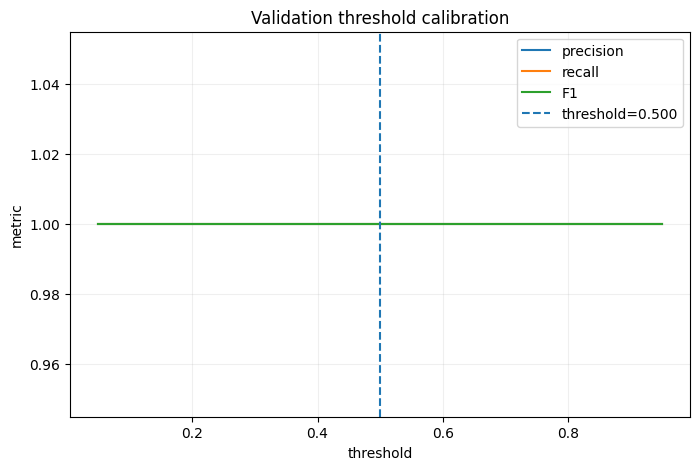

In [6]:
del model; gc.collect();
if torch.cuda.is_available(): torch.cuda.empty_cache()
model=AutoModelForSequenceClassification.from_pretrained(BEST).to(device).eval()
y_val,p_val,_=evaluate(val_loader)
rows=[]
for thr in np.linspace(0.05,0.95,181): rows.append({'threshold':float(thr),**metrics(y_val,(p_val>=thr).astype(int),p_val)})
sweep=pd.DataFrame(rows); eligible=sweep[sweep.positive_recall>=TARGET_RECALL].copy()
if len(eligible):
    eligible['distance']=(eligible.threshold-0.5).abs(); chosen=eligible.sort_values(['positive_precision','positive_f1','distance'],ascending=[False,False,True]).iloc[0]; policy=f'max_precision_subject_to_recall>={TARGET_RECALL}'
else:
    chosen=sweep.sort_values(['positive_f1','macro_f1'],ascending=False).iloc[0]; policy='fallback_max_positive_f1'
THRESHOLD=float(chosen.threshold); VAL_METRICS=metrics(y_val,(p_val>=THRESHOLD).astype(int),p_val)
print('Policy:',policy); print('Threshold:',THRESHOLD); print(json.dumps(VAL_METRICS,indent=2))
plt.figure(figsize=(8,5)); plt.plot(sweep.threshold,sweep.positive_precision,label='precision'); plt.plot(sweep.threshold,sweep.positive_recall,label='recall'); plt.plot(sweep.threshold,sweep.positive_f1,label='F1'); plt.axvline(THRESHOLD,linestyle='--',label=f'threshold={THRESHOLD:.3f}'); plt.xlabel('threshold'); plt.ylabel('metric'); plt.title('Validation threshold calibration'); plt.legend(); plt.grid(alpha=.2); plt.show()

# 5. Freeze point → untouched TEST
Model, tokenizer and threshold are frozen before TEST is opened.

In [7]:
test_loader=DataLoader(PrefDS(test_df),batch_size=BATCH_SIZE*2,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True,collate_fn=collate)
t0=time.perf_counter(); y_test,p_test,_=evaluate(test_loader); eval_s=time.perf_counter()-t0
test_pred=(p_test>=THRESHOLD).astype(int); TEST_METRICS=metrics(y_test,test_pred,p_test); TEST_METRICS['evaluation_time_s']=float(eval_s); TEST_METRICS['examples_per_second']=float(len(test_df)/eval_s)
print('FINAL TEST'); print(json.dumps(TEST_METRICS,indent=2)); print(classification_report(y_test,test_pred,target_names=[LABELS[0],LABELS[1]],digits=5))

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Evaluate:   0%|          | 0/125 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


FINAL TEST
{
  "accuracy": 1.0,
  "positive_precision": 1.0,
  "positive_recall": 1.0,
  "positive_f1": 1.0,
  "macro_precision": 1.0,
  "macro_recall": 1.0,
  "macro_f1": 1.0,
  "tn": 2000,
  "fp": 0,
  "fn": 0,
  "tp": 2000,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "roc_auc": 1.0,
  "average_precision": 0.9999999999999999,
  "evaluation_time_s": 9.652297290000092,
  "examples_per_second": 414.40911731387024
}
                      precision    recall  f1-score   support

NO_PREFERENCE_SIGNAL    1.00000   1.00000   1.00000      2000
   PREFERENCE_SIGNAL    1.00000   1.00000   1.00000      2000

            accuracy                        1.00000      4000
           macro avg    1.00000   1.00000   1.00000      4000
        weighted avg    1.00000   1.00000   1.00000      4000



## 6. Robustness by language and stress family + final error analysis
These results are for reporting only; do not retune on TEST failures.

In [8]:
res=test_df.copy(); res['prob_preference_signal']=p_test; res['pred_label_id']=test_pred; res['pred_label']=[LABELS[int(x)] for x in test_pred]; res['correct']=res.label_id==res.pred_label_id
def grouped(col):
    out=[]
    for name,g in res.groupby(col): out.append({col:name,'n':len(g),**metrics(g.label_id.to_numpy(),g.pred_label_id.to_numpy(),g.prob_preference_signal.to_numpy())})
    return pd.DataFrame(out)
LANG_METRICS=grouped('language'); STRESS_METRICS=grouped('stress_family')
display(LANG_METRICS); display(STRESS_METRICS.sort_values('macro_f1'))
FN=res[(res.label_id==1)&(res.pred_label_id==0)].sort_values('prob_preference_signal'); FP=res[(res.label_id==0)&(res.pred_label_id==1)].sort_values('prob_preference_signal',ascending=False)
print('False negatives:',len(FN),'False positives:',len(FP)); display(FN[['text','language','stress_family','prob_preference_signal']].head(20)); display(FP[['text','language','stress_family','prob_preference_signal']].head(20))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_r

,language,n,accuracy,positive_precision,positive_recall,positive_f1,macro_precision,macro_recall,macro_f1,tn,fp,fn,tp,false_positive_rate,false_negative_rate,roc_auc,average_precision
0,en,1600,1.0,1.0,1.0,1.0,1.0,1.0,1.0,800,0,0,800,0.0,0.0,1.0,1.0
1,fr,1600,1.0,1.0,1.0,1.0,1.0,1.0,1.0,800,0,0,800,0.0,0.0,1.0,1.0
2,mixed,800,1.0,1.0,1.0,1.0,1.0,1.0,1.0,400,0,0,400,0.0,0.0,1.0,1.0


,stress_family,n,accuracy,positive_precision,positive_recall,positive_f1,macro_precision,macro_recall,macro_f1,tn,fp,fn,tp,false_positive_rate,false_negative_rate,roc_auc,average_precision
0,comparative,200,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,200,0.0,0.0,NaN,1.0
1,concept_mention_only,200,1.0,0.0,0.0,0.0,1.0,1.0,1.0,200,0,0,0,0.0,0.0,NaN,0.0
2,descriptive_system_fact,200,1.0,0.0,0.0,0.0,1.0,1.0,1.0,200,0,0,0,0.0,0.0,NaN,0.0
3,historical_observation,200,1.0,0.0,0.0,0.0,1.0,1.0,1.0,200,0,0,0,0.0,0.0,NaN,0.0
4,hpc_hard_negative,200,1.0,0.0,0.0,0.0,1.0,1.0,1.0,200,0,0,0,0.0,0.0,NaN,0.0
5,long_context_negative,200,1.0,0.0,0.0,0.0,1.0,1.0,1.0,200,0,0,0,0.0,0.0,NaN,0.0
6,long_context_positive,200,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,200,0.0,0.0,NaN,1.0
7,mixed_requirement_preference,200,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,200,0.0,0.0,NaN,1.0
8,multi_preference,200,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,200,0.0,0.0,NaN,1.0
9,multi_quantity_no_preference,200,1.0,0.0,0.0,0.0,1.0,1.0,1.0,200,0,0,0,0.0,0.0,NaN,0.0


False negatives: 0 False positives: 0


,text,language,stress_family,prob_preference_signal


,text,language,stress_family,prob_preference_signal


## 7. Production inference helper and smoke tests

In [9]:
@torch.no_grad()
def predict_signal(text):
    x=tokenizer(text,truncation=True,max_length=MAX_LENGTH,return_tensors='pt'); x={k:v.to(device) for k,v in x.items()}
    p=torch.softmax(model(**x).logits,-1)[0,1].item(); y=int(p>=THRESHOLD)
    return {'text':text,'label_id':y,'label':LABELS[y],'probability':p,'threshold':THRESHOLD}
PROBES=[('Maximum power is 15 kW.',0),('The budget must remain below $100,000.',0),('Target read throughput is 80 GB/s.',0),('We need 500 TiB and 200 clients.',0),('Performance is our main priority.',1),('Reliability is absolutely critical.',1),('Cost is not important to us.',1),('Keeping power consumption low matters a lot.',1),('We are willing to spend more if that makes the system more reliable.',1),('La fiabilité est notre priorité absolue.',1),('La puissance maximale est de 15 kW.',0),('Performance est très importante mais le cost est secondaire.',1),('Performnce is our top priorty.',1),('The report contains reliability statistics.',0)]
probe=[]
for text,gold in PROBES:
    o=predict_signal(text); o['gold']=gold; o['pass']=o['label_id']==gold; probe.append(o)
PROBE_DF=pd.DataFrame(probe); display(PROBE_DF); print('Smoke accuracy:',PROBE_DF['pass'].mean())

,text,label_id,label,probability,threshold,gold,pass
0,Maximum power is 15 kW.,0,NO_PREFERENCE_SIGNAL,0.003640,0.5,0,True
1,"The budget must remain below $100,000.",0,NO_PREFERENCE_SIGNAL,0.000309,0.5,0,True
2,Target read throughput is 80 GB/s.,0,NO_PREFERENCE_SIGNAL,0.000728,0.5,0,True
3,We need 500 TiB and 200 clients.,1,PREFERENCE_SIGNAL,0.999536,0.5,0,False
4,Performance is our main priority.,1,PREFERENCE_SIGNAL,0.999838,0.5,1,True
5,Reliability is absolutely critical.,1,PREFERENCE_SIGNAL,0.999841,0.5,1,True
6,Cost is not important to us.,1,PREFERENCE_SIGNAL,0.999841,0.5,1,True
7,Keeping power consumption low matters a lot.,1,PREFERENCE_SIGNAL,0.999837,0.5,1,True
8,We are willing to spend more if that makes the...,1,PREFERENCE_SIGNAL,0.999853,0.5,1,True
9,La fiabilité est notre priorité absolue.,1,PREFERENCE_SIGNAL,0.999842,0.5,1,True


Smoke accuracy: 0.9285714285714286


## 8. Local single-message latency

In [10]:
for _ in range(10): predict_signal('Reliability is important.')
lat=[]; texts=['Performance is our top priority.','Maximum power is 15 kW.','La fiabilité est très importante.','We can spend more for reliability.']*25
for text in texts:
    if device.type=='cuda': torch.cuda.synchronize()
    t=time.perf_counter(); predict_signal(text)
    if device.type=='cuda': torch.cuda.synchronize()
    lat.append(time.perf_counter()-t)
LATENCY_METRICS={'n':len(lat),'mean_ms':float(np.mean(lat)*1000),'median_ms':float(np.median(lat)*1000),'p95_ms':float(np.percentile(lat,95)*1000),'max_ms':float(np.max(lat)*1000),'device':str(device)}
print(json.dumps(LATENCY_METRICS,indent=2))

{
  "n": 100,
  "mean_ms": 4.0186424900036855,
  "median_ms": 3.991096499987634,
  "p95_ms": 4.508978499984551,
  "max_ms": 4.753804999950262,
  "device": "cuda"
}


## 9. Export production artifact
The ZIP contains model, tokenizer, labels, calibrated threshold, metrics and predictions for local integration.

In [11]:
FINAL=OUT/'production_artifact'
if FINAL.exists(): shutil.rmtree(FINAL)
(FINAL/'model').mkdir(parents=True); (FINAL/'tokenizer').mkdir(parents=True)
model.save_pretrained(FINAL/'model'); tokenizer.save_pretrained(FINAL/'tokenizer')
def dump(name,obj):
    with open(FINAL/name,'w',encoding='utf-8') as f: json.dump(obj,f,indent=2,ensure_ascii=False)
dump('labels.json',{'id2label':{str(k):v for k,v in LABELS.items()},'label2id':{v:k for k,v in LABELS.items()}})
dump('thresholds.json',{'preference_signal_probability_threshold':THRESHOLD,'calibration_policy':policy,'target_positive_recall':TARGET_RECALL})
dump('training_config.json',{'model_name':MODEL_NAME,'seed':SEED,'max_length':MAX_LENGTH,'batch_size':BATCH_SIZE,'grad_accum_steps':GRAD_ACCUM_STEPS,'learning_rate':LR,'max_epochs':MAX_EPOCHS,'best_epoch':best_epoch,'train_size':len(train_df),'validation_size':len(val_df),'test_size':len(test_df)})
dump('validation_metrics.json',VAL_METRICS); dump('test_metrics.json',TEST_METRICS); dump('latency_metrics.json',LATENCY_METRICS); dump('training_history.json',history)
LANG_METRICS.to_csv(FINAL/'test_metrics_by_language.csv',index=False); STRESS_METRICS.to_csv(FINAL/'test_metrics_by_stress_family.csv',index=False); sweep.to_csv(FINAL/'validation_threshold_sweep.csv',index=False); res.to_json(FINAL/'test_predictions.jsonl',orient='records',lines=True,force_ascii=False); PROBE_DF.to_csv(FINAL/'production_smoke_probes.csv',index=False)
ZIP=Path('/kaggle/working/preference_signal_detector_v1_production.zip')
if ZIP.exists(): ZIP.unlink()
with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as z:
    for p in FINAL.rglob('*'):
        if p.is_file(): z.write(p,p.relative_to(FINAL.parent))
print('FINAL ZIP:',ZIP); print('Size MB:',ZIP.stat().st_size/1024**2)

FINAL ZIP: /kaggle/working/preference_signal_detector_v1_production.zip
Size MB: 480.229528427124


## 10. Final summary
If TEST metrics, subgroup robustness and smoke probes are satisfactory, freeze Layer 1 and integrate the exported artifact into the project.

In [12]:
print('MODEL:',MODEL_NAME); print('BEST EPOCH:',best_epoch); print('THRESHOLD:',THRESHOLD)
print('\nVALIDATION:',json.dumps(VAL_METRICS,indent=2)); print('\nTEST:',json.dumps(TEST_METRICS,indent=2)); print('\nLATENCY:',json.dumps(LATENCY_METRICS,indent=2)); print('\nSMOKE:',f"{int(PROBE_DF['pass'].sum())}/{len(PROBE_DF)} PASS"); print('\nARTIFACT: /kaggle/working/preference_signal_detector_v1_production.zip')

MODEL: distilbert-base-multilingual-cased
BEST EPOCH: 1
THRESHOLD: 0.49999999999999994

VALIDATION: {
  "accuracy": 1.0,
  "positive_precision": 1.0,
  "positive_recall": 1.0,
  "positive_f1": 1.0,
  "macro_precision": 1.0,
  "macro_recall": 1.0,
  "macro_f1": 1.0,
  "tn": 2000,
  "fp": 0,
  "fn": 0,
  "tp": 2000,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "roc_auc": 1.0,
  "average_precision": 0.9999999999999999
}

TEST: {
  "accuracy": 1.0,
  "positive_precision": 1.0,
  "positive_recall": 1.0,
  "positive_f1": 1.0,
  "macro_precision": 1.0,
  "macro_recall": 1.0,
  "macro_f1": 1.0,
  "tn": 2000,
  "fp": 0,
  "fn": 0,
  "tp": 2000,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "roc_auc": 1.0,
  "average_precision": 0.9999999999999999,
  "evaluation_time_s": 9.652297290000092,
  "examples_per_second": 414.40911731387024
}

LATENCY: {
  "n": 100,
  "mean_ms": 4.0186424900036855,
  "median_ms": 3.991096499987634,
  "p95_ms": 4.508978499984551,
  "max_m